# Generating Score ML

In [1]:
from Codes.ML_PIPELINE import ML_MonthlyProdPipeline
%load_ext autoreload
%autoreload 2

import Config.config_EU_test_backtest as config
predictor = ML_MonthlyProdPipeline(  
    config.CONFIG,  
    mode="backtest",
    preprocessing=False,
    update_score_ML=True,
    allow_multiprocessing=False,
    output_path=r"\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\DEEP_LEARNING_PROD\Output_files",
    output_file="MLP_backtest"
)  

predictor.run() 

c:\Users\GONONDYA\AppData\Local\anaconda3\envs\Y1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Debut REPRISE SCORE
Period to predict is : [1.0]
Output will be saved at \\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\DEEP_LEARNING_PROD\Output_files\MLP_backtest
Number of batches to predict is : 16
No multi processing, sequential method is used for generating backtest...


Generating Backtest:   0%|          | 0/16 [00:00<?, ?parameter/s]


AttributeError: 'MLP' object has no attribute 'input_dimrt'

In [7]:
import pandas as pd
from Codes.MLP_prod import MLP                                                                                                                                 

In [8]:
x=pd.read_pickle(r"\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\DEEP_LEARNING_PROD\Input_files\screen_ML_prod_EU.pkl")

In [9]:
X_backtest=pd.read_pickle(r"\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\DEEP_LEARNING_PROD\Output_files\MLP_backtest.pkl")
path =r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\0_SCREEN_AGG\backup_screen\screen_aggregate_20250605_before_cyc.pkl"
screen_agg = pd.read_pickle(path)

In [15]:
import sys
sys.path.append(r"\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick")
from myclass.Backtest import generation_sec_list
path_returns = r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\0_RETURNS\returns.pkl"
returns=pd.read_pickle(path_returns)
liste_noire =r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_BASE\_ ESG DATA\Liste_Noire_Exclusion.xlsx"
secto_eu = pd.read_excel(r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\3_Sec_List_Backtest\reco_secto_facto.xlsx", sheet_name="secto_eu", index_col=0)
secto_eu = secto_eu/5*3

################ Version tilt 3% ################
metrics='Score ML'
percentile=0.1
bench= "STOXX EUROPE 600"
ptf_name='ML EU Q1'
ponderation='Market cap' 
output_dir=''
cut_mkt_cap=0
score_neutral="ICB 19"
weight_neutral="ICB 19"


start_date = '2010-01-01'
reco_secto = secto_eu
top_mandatory = 3
top_mandatory_with_bench_weight = False

# ESG
esg_exclusion=0

myfunc=generation_sec_list(screen_agg,returns, bench, percentile, start_date,metrics, ptf_name, reco_secto=reco_secto,
                            ponderation=ponderation,esg_exclusion=esg_exclusion, cut_mkt_cap=cut_mkt_cap, 
                            score_neutral=score_neutral,
                            weight_neutral=weight_neutral,top_mandatory = top_mandatory,liste_noire=liste_noire,
                            top_mandatory_with_bench_weight = top_mandatory_with_bench_weight)

perf_ttr, buy_list=myfunc.backtest()

\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\myclass\Backtest.py:203: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Multi Avg Percentile'] = df[list_style].mean(skipna= False, axis=1)
\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\myclass\Backtest.py:205: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = date
\\groupe-ufg.COM\Commun\Prive\GestionAM\Ingenierie_Financiere\DOSSIERS_UTILISATEURS\Yannick\mycl

In [16]:
perf_bench=myfunc.get_bench_perf(screen_agg)

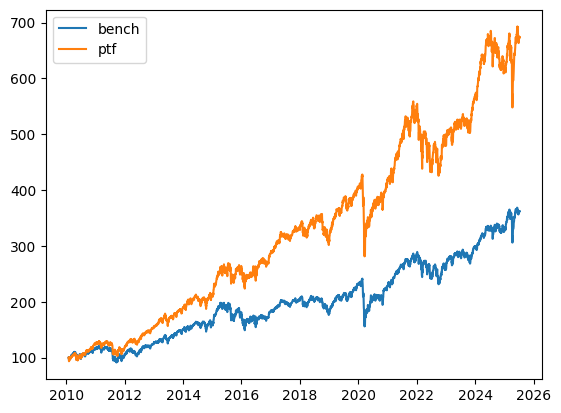

In [17]:
import matplotlib.pyplot as plt 
plt.plot(perf_bench,label='bench')
plt.plot(perf_ttr,label='ptf')
plt.legend()
plt.show()

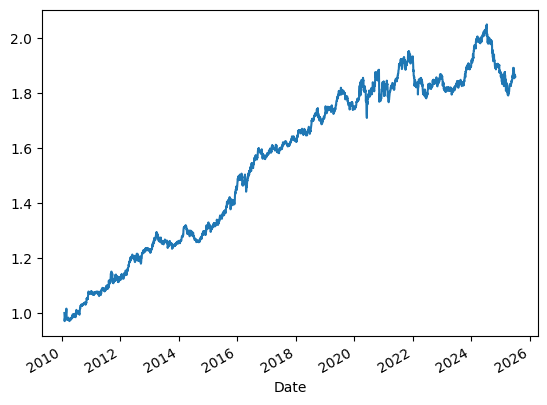

In [18]:
(perf_ttr/perf_bench).plot()
plt.show()